## Customer Churn Prediction

#### Business Probelm: - The Customer Churn from a service is important to company because losing customers directly affects company revenue.The goal was to predict whether a customer is likely to leave the service so that the company can take proactive actions to retain those customers. This model predicts Whether the customer is going to churn or not.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\rahul\Downloads\Customer_Churn_20k.csv")

In [3]:
df

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,3,1,34,0,1744,44,20,15,3,1,2,30,168.775,0
1,0,0,24,0,520,4,14,1,4,1,2,45,48.100,0
2,13,0,37,2,4464,74,3,32,1,1,1,15,260.946,0
3,7,0,37,0,15240,179,148,30,2,1,1,25,1359.855,0
4,17,0,29,4,1782,53,50,32,2,1,1,25,303.728,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11,0,44,3,8087,139,397,45,3,1,1,30,1886.362,0
19996,0,0,37,0,2351,27,267,12,3,1,1,30,1139.063,0
19997,19,0,30,0,260,35,4,10,2,1,2,25,28.728,1
19998,12,0,39,1,6628,106,15,12,3,1,1,30,329.360,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            20000 non-null  int64  
 1   Complains                20000 non-null  int64  
 2   Subscription  Length     20000 non-null  int64  
 3   Charge  Amount           20000 non-null  int64  
 4   Seconds of Use           20000 non-null  int64  
 5   Frequency of use         20000 non-null  int64  
 6   Frequency of SMS         20000 non-null  int64  
 7   Distinct Called Numbers  20000 non-null  int64  
 8   Age Group                20000 non-null  int64  
 9   Tariff Plan              20000 non-null  int64  
 10  Status                   20000 non-null  int64  
 11  Age                      20000 non-null  int64  
 12  Customer Value           20000 non-null  float64
 13  Churn                    20000 non-null  int64  
dtypes: float64(1), int64(1

In [5]:
df.shape

(20000, 14)

In [6]:
cols = ['Call  Failure', 'Complains', 'Age Group', 'Age','Tariff Plan']

df[cols] = df[cols].round().astype(int)

In [7]:
df.duplicated().sum()

np.int64(1311)

In [8]:
df = df.drop_duplicates()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18689 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            18689 non-null  int64  
 1   Complains                18689 non-null  int64  
 2   Subscription  Length     18689 non-null  int64  
 3   Charge  Amount           18689 non-null  int64  
 4   Seconds of Use           18689 non-null  int64  
 5   Frequency of use         18689 non-null  int64  
 6   Frequency of SMS         18689 non-null  int64  
 7   Distinct Called Numbers  18689 non-null  int64  
 8   Age Group                18689 non-null  int64  
 9   Tariff Plan              18689 non-null  int64  
 10  Status                   18689 non-null  int64  
 11  Age                      18689 non-null  int64  
 12  Customer Value           18689 non-null  float64
 13  Churn                    18689 non-null  int64  
dtypes: float64(1), int64(13)
me

In [10]:
df.shape

(18689, 14)

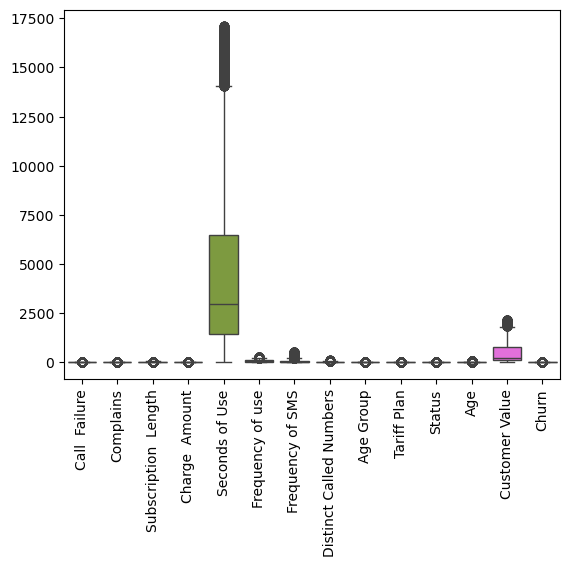

In [11]:
sns.boxplot(data = df)

plt.xticks(rotation=90)
plt.show()

In [12]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    return df

In [13]:
cols_to_cap = [
    "Seconds of Use",
    "Customer Value",
    "Charge  Amount",
    "Frequency of use",
    "Frequency of SMS"
]

df = cap_outliers(df, cols_to_cap)

C:\Users\rahul\AppData\Local\Temp\ipykernel_14960\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\rahul\AppData\Local\Temp\ipykernel_14960\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\rahul\AppData\Local\Temp\ipykernel_14960\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

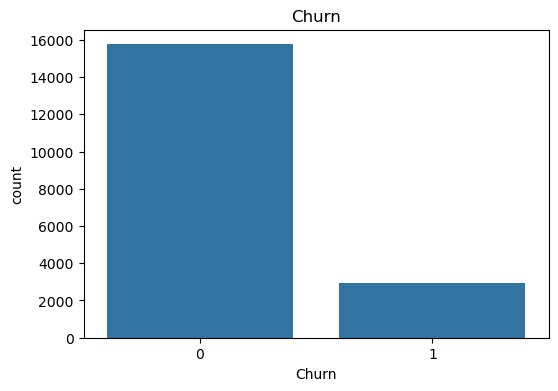

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn")
plt.show()

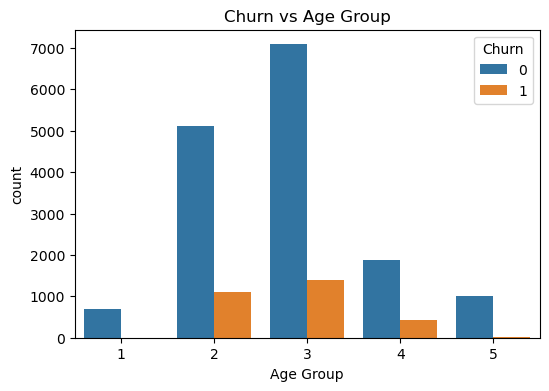

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age Group", hue="Churn")
plt.title("Churn vs Age Group")
plt.show()

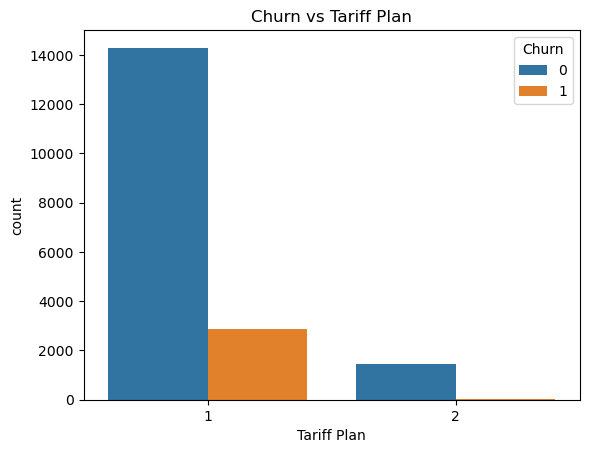

In [16]:
sns.countplot(data= df, x="Tariff Plan", hue="Churn")
plt.title("Churn vs Tariff Plan")
plt.show()

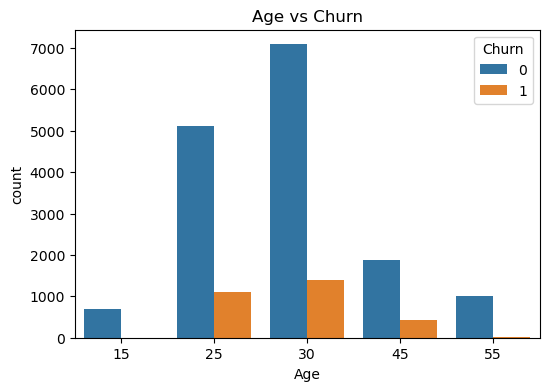

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age", hue="Churn")
plt.title("Age vs Churn")
plt.show()

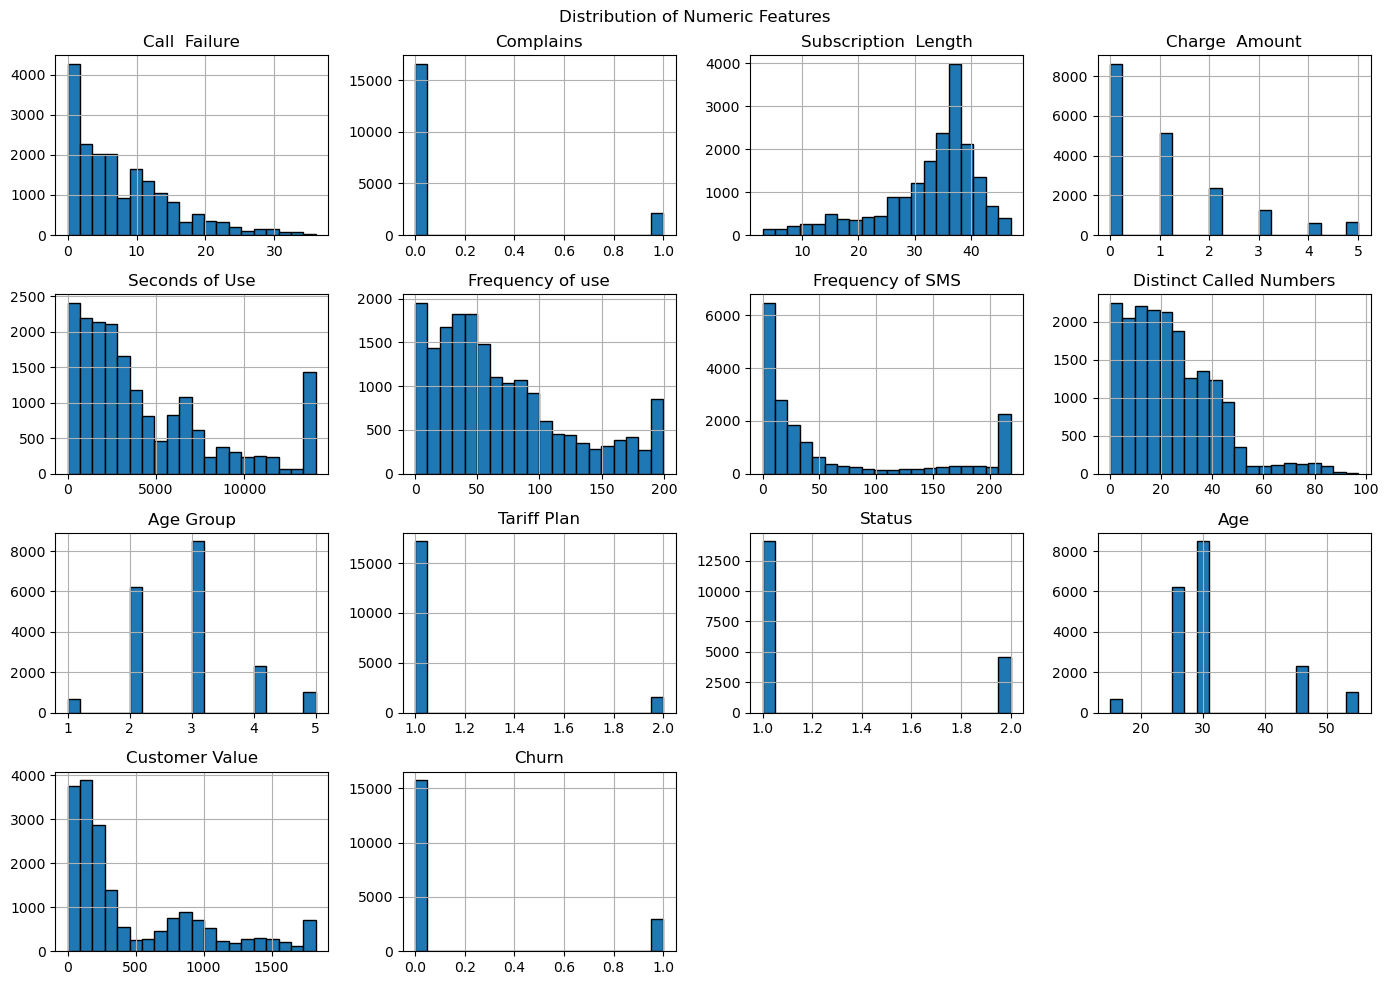

In [18]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(14,10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

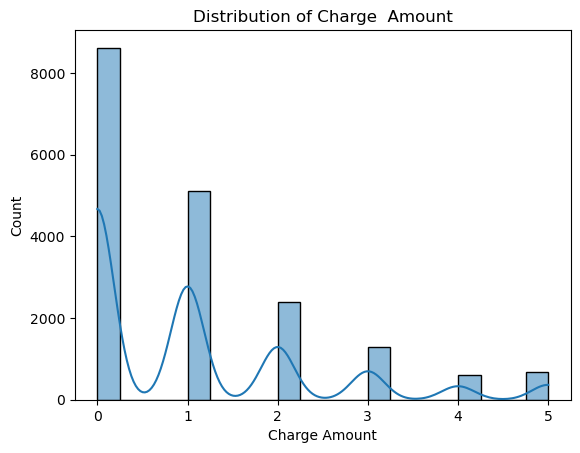

In [19]:
sns.histplot(df["Charge  Amount"],bins=20, kde=True)
plt.title("Distribution of Charge  Amount")
plt.xlabel("Charge Amount")
plt.ylabel("Count")
plt.show()

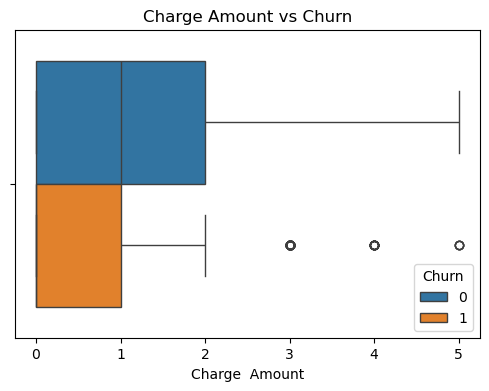

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Charge  Amount", hue="Churn")
plt.title("Charge Amount vs Churn")
plt.show()

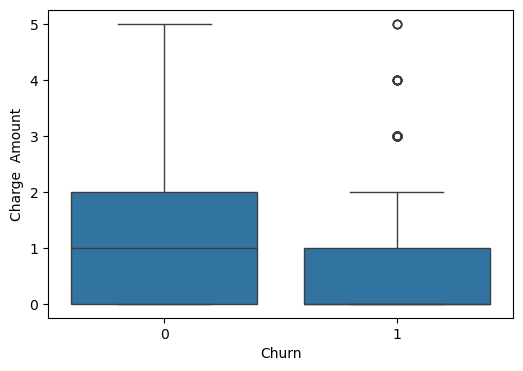

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="Charge  Amount")
plt.show()

In [22]:
# Churn imbalance check
df["Churn"].value_counts(normalize=True) * 100

Churn
0    84.316978
1    15.683022
Name: proportion, dtype: float64

In [23]:
## Check Skewness

df.select_dtypes(include="number").skew().sort_values(ascending=False)

Tariff Plan                3.076725
Complains                  2.452466
Churn                      1.887563
Charge  Amount             1.388824
Age                        1.274947
Customer Value             1.273875
Status                     1.182141
Frequency of SMS           1.173560
Seconds of Use             1.148332
Call  Failure              1.124439
Distinct Called Numbers    1.030940
Frequency of use           0.910807
Age Group                  0.493770
Subscription  Length      -1.202458
dtype: float64

In [24]:
df.head(2)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,3,1,34,0,1744,44.0,20.0,15,3,1,2,30,168.775,0
1,0,0,24,0,520,4.0,14.0,1,4,1,2,45,48.100,0


In [25]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

Churn                      1.000000
Status                     0.496066
Complains                  0.407044
Call  Failure             -0.006770
Age Group                 -0.022984
Age                       -0.028610
Subscription  Length      -0.036554
Tariff Plan               -0.105186
Charge  Amount            -0.183903
Frequency of SMS          -0.246797
Distinct Called Numbers   -0.276531
Customer Value            -0.295495
Seconds of Use            -0.303025
Frequency of use          -0.307939
Name: Churn, dtype: float64

#### Feature preparation

In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14951, 13)
(3738, 13)
(14951,)
(3738,)


In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [29]:
X_train_trans = preprocess.fit_transform(X_train)
X_test_trans = preprocess.transform(X_test)

In [30]:
X_train_trans = pd.DataFrame(X_train_trans)
X_train_trans.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.522416,-0.359367,-0.170202,-0.790517,-0.498138,-0.318637,1.462450,0.022271,-0.927741,-0.296211,-0.571506,-0.680085,0.950554
1,-0.384584,-0.359367,0.057817,-0.790517,-0.431283,-0.337203,1.501436,-0.266665,-0.927741,-0.296211,-0.571506,-0.680085,0.788512


In [31]:
X_test_trans = pd.DataFrame(X_test_trans)
X_test_trans.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.108921,2.782674,0.627864,-0.030305,-0.283645,-0.745648,2.053733,-0.786751,0.195389,-0.296211,-0.571506,-0.112392,2.724800
1,1.131563,-0.359367,-0.056193,0.729908,2.444751,2.438368,-0.447849,0.253420,0.195389,-0.296211,-0.571506,-0.112392,0.581833


### KNN

In [32]:
## model Knn Classifiers
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors= 11,
    weights="uniform",
    metric="minkowski"
)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [33]:
y_pred = knn.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
print(acc)

0.8649010165864098


In [34]:
y_pred_train = knn.predict(X_train)
acc_train = accuracy_score(y_train,y_pred_train)
print(acc_train)

0.8858270349809377


In [35]:
## observation:- using knn is was giving more gap which is not suitable for churn data, by using k neigbhor = 11 it give less gap
## or after tuning it accuracy is better

### Naive bayes

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('prep',preprocess),
    ('model',GaussianNB())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred)
print(acc_nb)

0.7330123060460139


In [37]:
y_pred_train = pipe.predict(X_train)
acc_train_nb = accuracy_score(y_train,y_pred_train)
print(acc_train_nb)

0.7300515015718012


 It gave an accuracy of 74 ,This indicates no overfitting, but Naive Bayes may be too simple for the dataset.

### Decision tree

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipe1 = Pipeline([
    ('prep',preprocess),
    ('model',DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        
    ))
])

pipe1.fit(X_train, y_train)

y_pred_dt = pipe1.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(acc_dt)

0.9146602461209202


In [39]:
y_pred1_dt = pipe1.predict(X_train)
acc_dt_train = accuracy_score(y_train, y_pred1_dt)
print(acc_dt_train)

0.9166610929034847


In [40]:
# By using max_depth it acctually reduces the gap(overfitting) and model get best fit by train and test accuracy of 91

In [41]:
from sklearn.metrics import classification_report
y_pred = pipe1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3161
           1       0.82      0.57      0.67       577

    accuracy                           0.91      3738
   macro avg       0.87      0.78      0.81      3738
weighted avg       0.91      0.91      0.91      3738



 The initial Decision Tree showed slight overfitting; max_depth tuning was performed to improve generalization.

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

pipe2 = Pipeline([
    ('prep', preprocess),
    ('model',LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
    
])

pipe2.fit(X_train, y_train)
y_pred_lr = pipe2.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(acc_lr)

0.833868378812199


In [43]:
y_pred1_lr = pipe2.predict(X_train)
acc_lr_train = accuracy_score(y_train, y_pred1_lr)
print(acc_lr_train)

0.8327202193833189


In [44]:
## The Logistic regression give acuracy of 8 But less than the decision tree model

## Random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
print("Random forest accuracy: ", accuracy_score(y_test, y_pred_rf))

Random forest accuracy:  0.9622792937399679


In [46]:
y_pred1_rf = rf_pipe.predict(X_train)
print("Random forest accuracy: ", accuracy_score(y_train, y_pred1_rf))

Random forest accuracy:  0.9717744632466055


In [47]:
from sklearn.metrics import classification_report
y_pred_rf_ = rf_pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3161
           1       0.82      0.57      0.67       577

    accuracy                           0.91      3738
   macro avg       0.87      0.78      0.81      3738
weighted avg       0.91      0.91      0.91      3738



----Random Forest achieved the best balance between accuracy and generalization with 96% accuracy in test and 97 in train , which has no overfitting and suitable for this dataset. demonstrating strong model generalization and predictive performance for customer churn prediction.


### XGBoost

In [48]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [49]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
xgb_pipe = Pipeline([
    ('prep', preprocess),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
print("XGBoost Accuracy ", accuracy_score(y_test,y_pred_xgb))

XGBoost Accuracy  0.9686998394863563


In [50]:
y_pred1_xgb = xgb_pipe.predict(X_train)
print("XGBoost train accuracy:", accuracy_score(y_train, y_pred1_xgb))

XGBoost train accuracy: 0.9810715002340981


--- XGBoost also gives the better accurracy but slight overfitting with training accuracy of 98% and test is 96%

--- We choose the Random forest model for our dataset because it gives strong accuracy, less overfitting

In [51]:
import pickle

In [52]:
with open("churn_pred.pkl","wb") as file:
    pickle.dump(rf_pipe, file)